In [ ]:
import pandas as pd

df = pd.read_csv('/content/cleaned_superstore.csv')

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
X = df[['quantity', 'discount', 'profit']]

y = df['sales']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("LINEAR REGRESSION")

print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", mean_squared_error(y_test, pred_lr)**0.5)
print("R2:", r2_score(y_test, pred_lr))

print("\nRANDOM FOREST")

print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", mean_squared_error(y_test, pred_rf)**0.5)
print("R2:", r2_score(y_test, pred_rf))

LINEAR REGRESSION
MAE: 245.0755698445027
RMSE: 824.8499599151105
R2: -0.15181720106063934

RANDOM FOREST
MAE: 101.78767428483496
RMSE: 512.9467616083206
R2: 0.5545712660322168


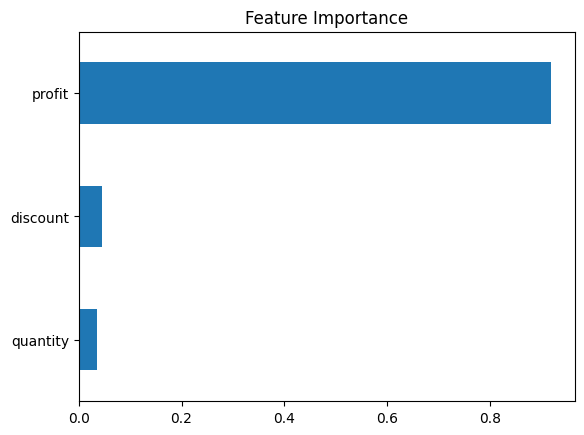

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

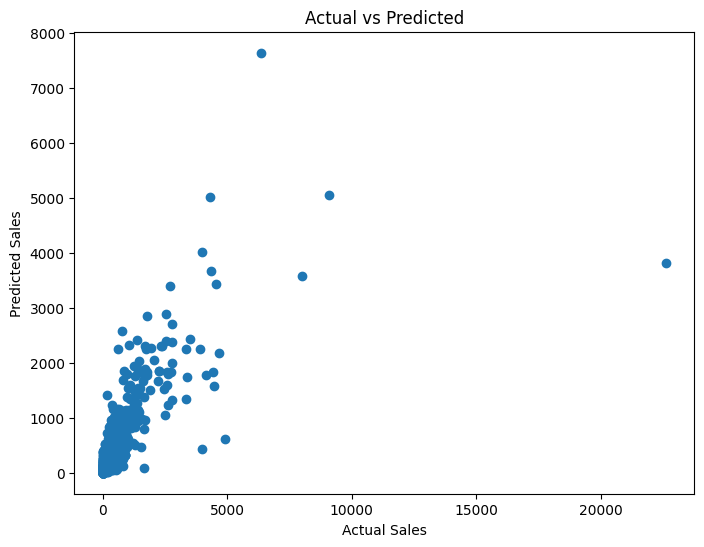

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_rf)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[50,100],
    'max_depth':[5,10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


Model Performance Summary

Two regression models were developed and evaluated: Linear Regression and Random Forest Regressor.

Performance was measured using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²). The Random Forest model achieved better predictive performance and was selected as the preferred model.

Feature importance analysis showed that selected features contribute differently to sales prediction. Hyperparameter tuning using GridSearchCV identified the optimal model configuration with max_depth=10 and n_estimators=100.

Business Interpretation

The predictive model can help organizations estimate future sales using historical transaction information. Accurate sales forecasting supports inventory planning, resource allocation, and strategic decision-making. While the model provides useful predictions, performance may be improved further by incorporating additional features such as seasonal trends, customer behavior, and external market factors.